# Citi Bike weekly-pattern hypothesis

**Contributions:** Tomislav requested task 10 on 7 October 2026. The statistical
helper, execution, figures and initial explanations were prepared with AI
assistance. Individual human reviews and substantive changes remain to be
recorded. See [the assistance record](../docs/AI_USE.md).

**Question:** does typical weekday usage differ from weekend usage when compared
within the same week? This tests one interpretable weekly contrast before
building a forecast model. It does not test every pair of weekdays.

We have already explored this development period in notebook 01, so this is
**exploratory inference, not a pre-registered confirmatory experiment**. The
analysis plan records one primary contrast and method; the larger Wednesday
versus Sunday difference is not selected as a new primary test after seeing it.

Only January-September 2023 is eligible. October-December remains aside as the
candidate final-test period. No model or final-test performance is evaluated.

## State the hypothesis and measure

For each complete Monday-Sunday week, calculate:

- `W`: the mean count for Monday-Friday (five daily observations).
- `E`: the mean count for Saturday-Sunday (two daily observations).
- `A`: the mean across all seven days.
- The paired difference `W - E` in rides per day.
- The normalized contrast `c = (W - E) / A`.

**Null hypothesis:** the mean normalized contrast is zero.
**Alternative:** it differs from zero; this is a two-sided test at alpha 0.05.

Comparing within a week limits confounding by the large between-week change in
usage. Dividing by that week's mean keeps the growing volume from giving busy
summer weeks more scale simply because they have more rides. This does not
remove within-week weather, holidays or other causes of calendar associations.

A contrast of 0.15 means the weekday-minus-weekend gap is 15% of the whole-week
daily mean. It is **not** a 15% increase relative to the weekend mean.

In [1]:
from pathlib import Path
import json
import sys
import numpy as np
import pandas as pd
ROOT = Path.cwd()
while not (ROOT / 'src/citibike_hypothesis.py').exists():
    if ROOT == ROOT.parent:
        raise RuntimeError('Open this notebook inside the repository folder.')
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))
from citibike import sha256_file
from citibike_hypothesis import analyse
plan = json.loads((ROOT / 'citibike/hypothesis_plan.json').read_text())
source_audit = json.loads((ROOT / 'citibike/archive_manifest.json').read_text())
data_path = ROOT / 'data/processed/citibike_daily.csv'
assert sha256_file(data_path) == source_audit['daily_sha256']
daily = pd.read_csv(data_path, index_col='date', parse_dates=['date'])
assert pd.Timestamp(plan['analysis_end']) < pd.Timestamp(plan['candidate_holdout_start'])
display(pd.Series({key: plan[key] for key in ['question', 'null_hypothesis', 'alternative_hypothesis',
    'analysis_start', 'analysis_end', 'primary_expected_block_weeks', 'bootstrap_replicates', 'seed']}, name='plan').to_frame())

,plan
question,Does average weekday usage differ from weekend...
null_hypothesis,The mean within-week weekday-minus-weekend con...
alternative_hypothesis,That mean normalized contrast is not zero (two...
analysis_start,2023-01-01
analysis_end,2023-09-30
primary_expected_block_weeks,4
bootstrap_replicates,20000
seed,42


## Form complete weeks

A week must contain exactly one observation for each weekday. Missing or
duplicated development dates stop the analysis. The two incomplete edge weeks
are excluded explicitly so a weekday or weekend is not disproportionately
represented. The comparison unit is a **week**, not one of the millions of
individual rides, and the weeks are not assumed independent.

In [2]:
weeks, result, bootstrap_draws = analyse(daily, plan)
print('Complete weeks:', result['complete_weeks'], '| included days:', result['included_days'])
print('Included:', result['first_included_date'], 'through', result['last_included_date'])
print('Excluded incomplete-week dates:', result['excluded_incomplete_week_dates'])
display(weeks.head().round(4))
print('Positive weekday-minus-weekend weeks:', result['positive_weeks'])
print('Negative weeks:', result['negative_weeks'])
assert result['candidate_final_test_used'] is False

Complete weeks: 38 | included days: 266
Included: 2023-01-02 through 2023-09-24
Excluded incomplete-week dates: ['2023-01-01', '2023-09-25', '2023-09-26', '2023-09-27', '2023-09-28', '2023-09-29', '2023-09-30']
Positive weekday-minus-weekend weeks: 31
Negative weeks: 7


,weekday_mean,weekend_mean,week_mean,difference_rides,normalized_contrast
week_start,,,,,
2023-01-02,64135.2,54306.0,61326.8571,9829.2,0.1603
2023-01-09,62425.4,42309.0,56677.8571,20116.4,0.3549
2023-01-16,58069.0,48815.0,55425.0000,9254.0,0.1670
2023-01-23,55597.0,62430.0,57549.2857,-6833.0,-0.1187
2023-01-30,57896.8,37326.0,52019.4286,20570.8,0.3954


## Estimate uncertainty while preserving nearby-week dependence

Our stationary bootstrap resamples runs of consecutive weekly contrasts.
Each resampled sequence starts at a uniformly selected week. It then either
continues to the next week or starts another randomly selected run. For the
primary expected run length of four weeks, restart probability is 1/4. Runs
can continue circularly from the last observation to the first.

We generate 20,000 sequences with seed 42 and calculate the mean contrast in
each. The interval is the basic (reverse-percentile) 95% bootstrap interval.
The approximate two-sided p-value uses the resampled errors after centering
at the observed mean, imposing a zero-mean null contrast. A plus-one correction
prevents reporting p = 0 from a finite simulation. This is an approximate
bootstrap test, not an exact randomized experiment.

The method requires approximately stationary, weakly dependent normalized
contrasts. Four weeks is a documented working choice, not an estimated optimal
length. We also report two and six weeks and do not choose the smallest p-value.

Method references: [Politis and Romano (1994)](https://doi.org/10.1080/01621459.1994.10476870)
and the [official stationary-bootstrap documentation](https://bashtage.github.io/arch/bootstrap/generated/arch.bootstrap.StationaryBootstrap.html).
The helper uses NumPy directly, so no additional package is required.

In [3]:
primary = result['primary']
summary = pd.Series({
    'mean weekday rides/day': result['mean_weekday_rides'],
    'mean weekend rides/day': result['mean_weekend_rides'],
    'paired gap in rides/day': result['mean_paired_difference_rides'],
    'mean normalized contrast (%)': 100 * primary['estimate'],
    '95% lower bound (%)': 100 * primary['ci_lower'],
    '95% upper bound (%)': 100 * primary['ci_upper'],
    'approximate two-sided bootstrap p': primary['approximate_two_sided_p'],
    'extreme null-centered replicates': primary['null_extreme_replicates'],
}, name='result')
display(summary.to_frame())
print('Monte Carlo resolution:', primary['monte_carlo_resolution'])
print('Decision:', result['decision'])

Monte Carlo resolution: 4.999750012499375e-05
Decision: Continue the proposed next-day recorded ride-count task; include calendar weekday as a candidate input. Chronological baseline/model evaluation and team scope agreement remain required.


,result
mean weekday rides/day,100783.573684
mean weekend rides/day,87316.486842
paired gap in rides/day,13467.086842
mean normalized contrast (%),15.595295
95% lower bound (%),8.942468
95% upper bound (%),21.879593
approximate two-sided bootstrap p,0.000050
extreme null-centered replicates,0.000000


## See individual weeks and the mean effect

The bars below show whether each week's weekdays were busier or quieter than
its weekend. Negative weeks are retained. A positive average is not a rule
that every individual weekday must exceed every weekend day.

No event loop hook running.


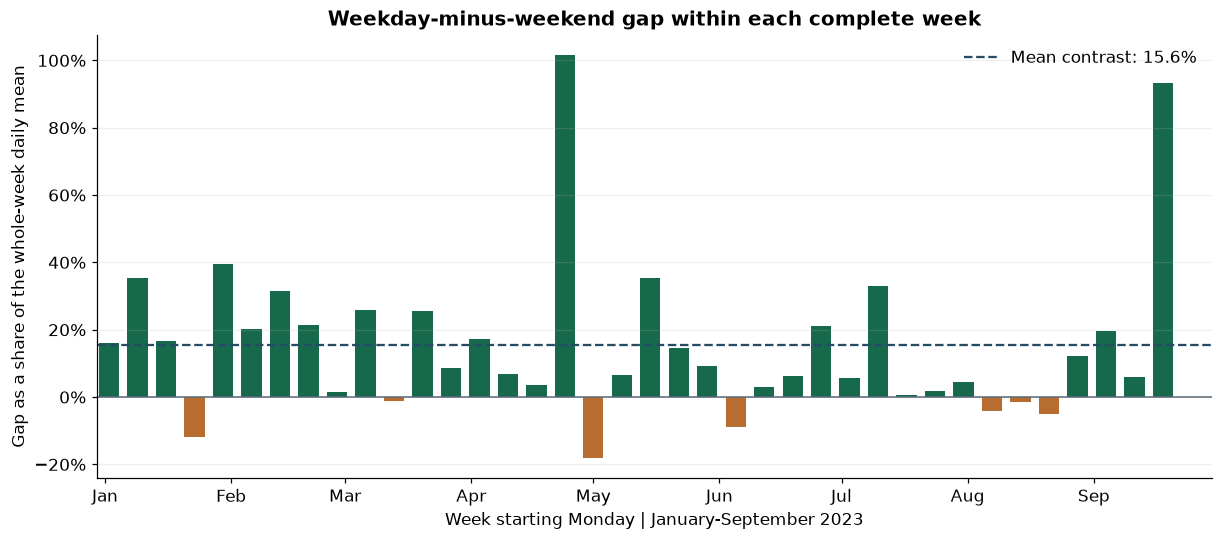

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import PercentFormatter
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.titleweight': 'bold'})
FIGURES = ROOT / 'citibike/figures'
FIGURES.mkdir(parents=True, exist_ok=True)
fig, ax = plt.subplots(figsize=(11, 4.8), layout='constrained')
colors = np.where(weeks['normalized_contrast'] >= 0, '#17694c', '#b66d2f')
ax.bar(weeks.index, weeks['normalized_contrast'], width=5, color=colors)
ax.axhline(0, color='#596774', linewidth=1)
ax.axhline(primary['estimate'], color='#244d65', linestyle='--',
           label=f"Mean contrast: {100*primary['estimate']:.1f}%")
ax.set(title='Weekday-minus-weekend gap within each complete week',
       ylabel='Gap as a share of the whole-week daily mean', xlabel='Week starting Monday | January-September 2023')
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.set_xlim(weeks.index.min() - pd.Timedelta(days=3), pd.Timestamp(plan['analysis_end']))
ax.grid(axis='y', alpha=0.2)
ax.legend(frameon=False)
fig.savefig(FIGURES / 'weekly_contrast.png', dpi=150)
plt.show()

## Interval and block-length sensitivity

The bootstrap distribution describes uncertainty in the **average** contrast,
not the spread of next-day forecast errors. Its interval is conditional on the
sampling assumptions and this development period. Sensitivity checks below
keep the same effect definition, seed and repetition count.

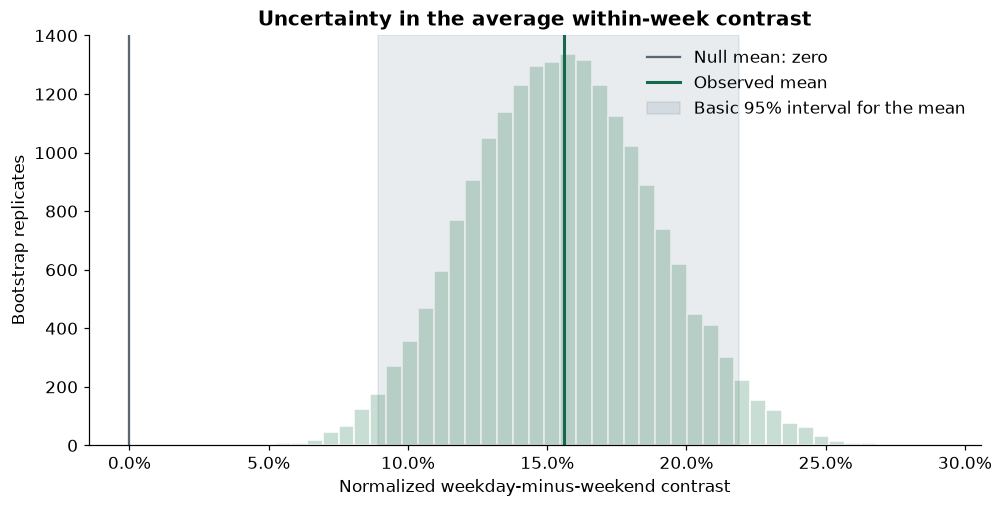

,expected_block_weeks,estimate,ci_lower,ci_upper,approximate_two_sided_p
0,2,0.155953,0.083316,0.220588,0.00005
1,4,0.155953,0.089425,0.218796,0.00005
2,6,0.155953,0.093934,0.216974,0.00005


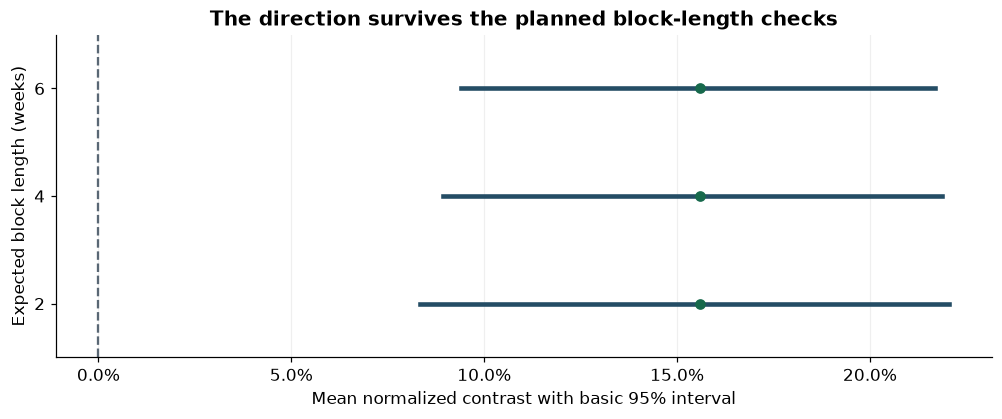

In [5]:
fig, ax = plt.subplots(figsize=(9, 4.5), layout='constrained')
ax.hist(bootstrap_draws, bins=45, color='#c8ddd3', edgecolor='white')
ax.axvline(0, color='#596774', linewidth=1.5, label='Null mean: zero')
ax.axvline(primary['estimate'], color='#17694c', linewidth=2, label='Observed mean')
ax.axvspan(primary['ci_lower'], primary['ci_upper'], color='#244d65', alpha=0.1,
           label='Basic 95% interval for the mean')
ax.set(title='Uncertainty in the average within-week contrast',
       xlabel='Normalized weekday-minus-weekend contrast', ylabel='Bootstrap replicates')
ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.legend(frameon=False)
fig.savefig(FIGURES / 'weekly_contrast_uncertainty.png', dpi=150)
plt.show()
sensitivity = pd.DataFrame(result['sensitivity'])
display(sensitivity[['expected_block_weeks', 'estimate', 'ci_lower', 'ci_upper',
                     'approximate_two_sided_p']])
fig, ax = plt.subplots(figsize=(9, 3.7), layout='constrained')
for row in sensitivity.itertuples():
    ax.plot([row.ci_lower, row.ci_upper], [row.expected_block_weeks]*2,
            color='#244d65', linewidth=3)
    ax.scatter(row.estimate, row.expected_block_weeks, color='#17694c', zorder=3)
ax.axvline(0, color='#596774', linestyle='--')
ax.set(title='The direction survives the planned block-length checks',
       xlabel='Mean normalized contrast with basic 95% interval', ylabel='Expected block length (weeks)',
       yticks=sensitivity['expected_block_weeks'], ylim=(1, 7))
ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.grid(axis='x', alpha=0.2)
fig.savefig(FIGURES / 'weekly_contrast_sensitivity.png', dpi=150)
plt.show()

## Check stability and explain limitations

Quarter descriptions are diagnostics, not additional hypothesis tests. They
are grouped by the Monday starting each complete week; a week can cross a
quarter boundary. The method does not prove strict stationarity from a short
sample. There may be longer dependence or structural changes beyond the run
lengths investigated.

Weather and holidays can differ between weekdays and weekends. Within-week
comparison reduces slow changes in level but does not identify a causal
effect of weekday. Earlier EDA also means a small p-value is not independent
confirmation. Future forecasting needs a chronological development comparison
and final test, rather than treating this inference as prediction accuracy.

In [6]:
display(pd.DataFrame(result['quarter_descriptives']))
display(pd.Series(result['weekly_contrast_autocorrelations'], name='weekly contrast autocorrelation').to_frame())
(ROOT / 'citibike/hypothesis_results.json').write_text(json.dumps(result, indent=2) + '\n', encoding='utf-8')
weekly_records = weeks.reset_index().copy()
weekly_records['week_start'] = weekly_records['week_start'].dt.strftime('%Y-%m-%d')
(ROOT / 'citibike/weekly_contrasts.json').write_text(
    json.dumps(weekly_records.to_dict(orient='records'), indent=2) + '\n', encoding='utf-8')
print('Saved the analysis result and all 38 weekly observations for review.')

Saved the analysis result and all 38 weekly observations for review.


,quarter_by_week_start,weeks,mean_normalized_contrast
0,1,13,0.176198
1,2,13,0.152271
2,3,12,0.138010


,weekly contrast autocorrelation
1,-0.235689
2,-0.006160
3,0.124817
4,-0.128676


## Project decision

The executed evidence and sensitivity checks support continuing the proposed
**next-day recorded citywide ride-count forecast**, with weekday/weekend
calendar information as a candidate input. Weekday is known before the
forecast date, so the feature does not require observing that day's rides.

This establishes an interpretable development-data association worth testing
in forecasts. It does not establish how much forecast MAE/RMSE will improve,
that the pattern repeats in other years, or that it is causal. Task 12 must
still lock chronological evaluation; tasks 14 and 16 must produce preparation
and forecast baselines. No final-test predictions have been made.

The team should review the working 2023 scope and this recommendation. Explain
the contrast denominator, the week as the unit of comparison, and why blocks
are resampled before calling the task understood.